# Heart Attack Possibility Prediction
Four classifiers (KNN, MLP, AdaBoost, Random Forest) on the UCI Heart Disease data.

`target`: 0 = less chance of heart attack, 1 = more chance of heart attack

## 1. Libraries

In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

SEED = 42
np.random.seed(SEED)

## 2. Load data (Kaggle path is found automatically)

In [3]:
path = glob.glob('/kaggle/input/**/heart.csv', recursive=True)[0]
print("Loading:", path)
df = pd.read_csv(path)
df.head()

Loading: /kaggle/input/datasets/humairatasnimadiba/heart-csv/heart.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3. Quick look
Columns: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


target
1    165
0    138
Name: count, dtype: int64


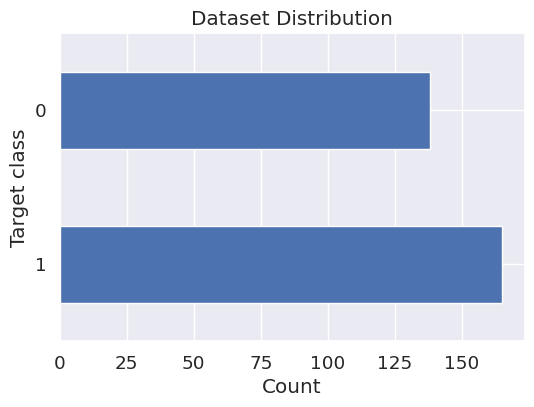

In [6]:
print(df['target'].value_counts())
sns.set(font_scale=1.2)
df['target'].value_counts().plot(kind='barh', figsize=(6, 4))
plt.xlabel("Count")
plt.ylabel("Target class")
plt.title("Dataset Distribution")
plt.show()

## 4. Split first, then scale
Scaling is fitted on the training set only, so the test set stays unseen (no data leakage).

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)
print(X_train.shape, X_test.shape)

(242, 13) (61, 13)


## 5. Models

In [8]:
labels = ["less chance", "more chance"]
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=7, weights='distance', metric='manhattan'),
    "MLP": MLPClassifier(activation='relu', solver='adam', max_iter=2600, alpha=0.0001, random_state=SEED),
    "AdaBoost": AdaBoostClassifier(n_estimators=250, learning_rate=0.01, random_state=SEED),
    "RF": RandomForestClassifier(n_estimators=100, max_features='sqrt', criterion='gini', random_state=SEED),
}

def plot_confusion(y_true, y_pred, title):
    cm = pd.DataFrame(confusion_matrix(y_true, y_pred), index=labels, columns=labels)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

KNN
CV accuracy (train): 0.818   Test accuracy: 0.754   AUC: 0.896
              precision    recall  f1-score   support

 less chance       0.84      0.57      0.68        28
 more chance       0.71      0.91      0.80        33

    accuracy                           0.75        61
   macro avg       0.78      0.74      0.74        61
weighted avg       0.77      0.75      0.75        61



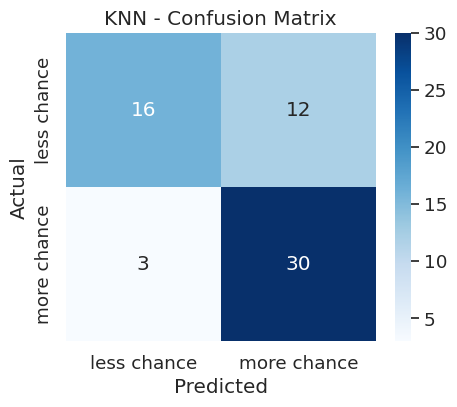

MLP
CV accuracy (train): 0.801   Test accuracy: 0.721   AUC: 0.835
              precision    recall  f1-score   support

 less chance       0.74      0.61      0.67        28
 more chance       0.71      0.82      0.76        33

    accuracy                           0.72        61
   macro avg       0.72      0.71      0.71        61
weighted avg       0.72      0.72      0.72        61



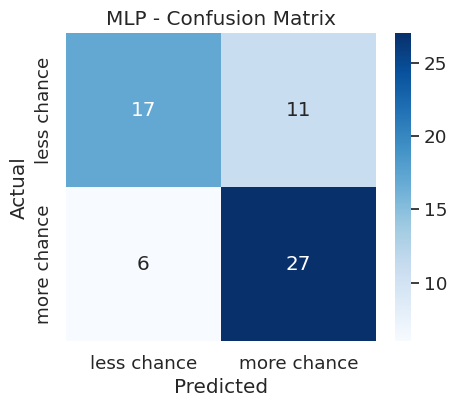

AdaBoost
CV accuracy (train): 0.830   Test accuracy: 0.820   AUC: 0.892
              precision    recall  f1-score   support

 less chance       0.95      0.64      0.77        28
 more chance       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



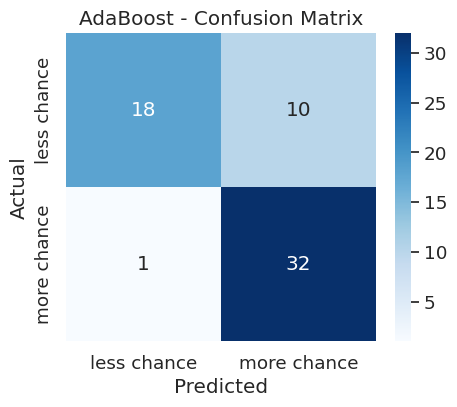

RF
CV accuracy (train): 0.830   Test accuracy: 0.836   AUC: 0.909
              precision    recall  f1-score   support

 less chance       0.95      0.68      0.79        28
 more chance       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



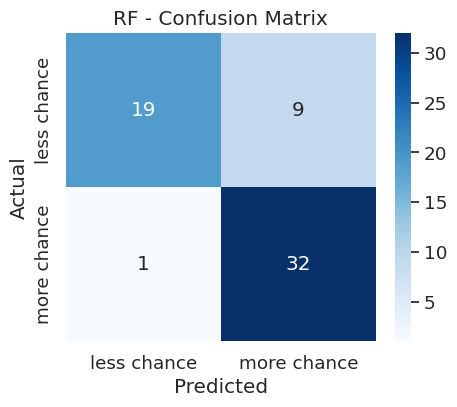

In [9]:
results = []
roc_data = {}

for name, model in models.items():
    print("=" * 60)
    print(name)
    print("=" * 60)

    cv_scores = cross_val_score(model, X_train, y_train, cv=kf)
    model.fit(X_train, y_train)

    test_acc = model.score(X_test, y_test)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(f"CV accuracy (train): {cv_scores.mean():.3f}   Test accuracy: {test_acc:.3f}   AUC: {auc:.3f}")
    print(classification_report(y_test, y_pred, target_names=labels))
    plot_confusion(y_test, y_pred, f"{name} - Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)
    results.append([name, cv_scores.mean(), test_acc, auc])

## 6. Compare models

In [10]:
summary = pd.DataFrame(results, columns=["Model", "CV Accuracy (train)", "Test Accuracy", "AUC"]).round(3)
summary

,Model,CV Accuracy (train),Test Accuracy,AUC
0,KNN,0.818,0.754,0.896
1,MLP,0.801,0.721,0.835
2,AdaBoost,0.830,0.820,0.892
3,RF,0.830,0.836,0.909


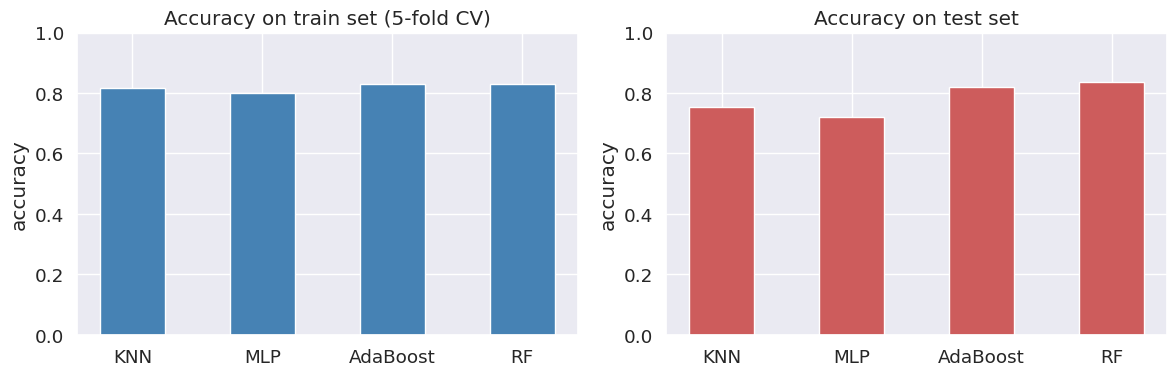

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(summary["Model"], summary["CV Accuracy (train)"], color="steelblue", width=0.5)
ax[0].set_title("Accuracy on train set (5-fold CV)")
ax[0].set_ylim(0, 1)
ax[1].bar(summary["Model"], summary["Test Accuracy"], color="indianred", width=0.5)
ax[1].set_title("Accuracy on test set")
ax[1].set_ylim(0, 1)
for a in ax:
    a.set_ylabel("accuracy")
plt.tight_layout()
plt.show()

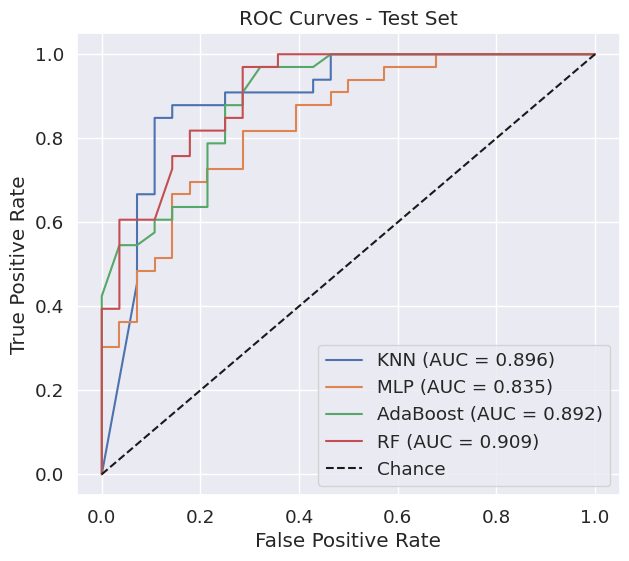

In [12]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Test Set")
plt.legend()
plt.show()

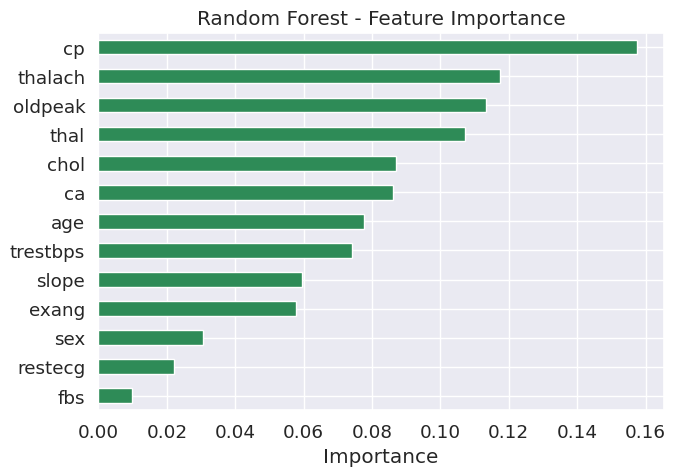

cp          0.157
thalach     0.117
oldpeak     0.113
thal        0.107
chol        0.087
ca          0.086
age         0.078
trestbps    0.074
slope       0.059
exang       0.058
sex         0.030
restecg     0.022
fbs         0.010
dtype: float64

In [13]:
importances = pd.Series(models["RF"].feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(7, 5))
importances.plot(kind="barh", color="seagreen")
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False).round(3)

Voting test accuracy: 0.803
Voting AUC: 0.897

              precision    recall  f1-score   support

 less chance       0.86      0.68      0.76        28
 more chance       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



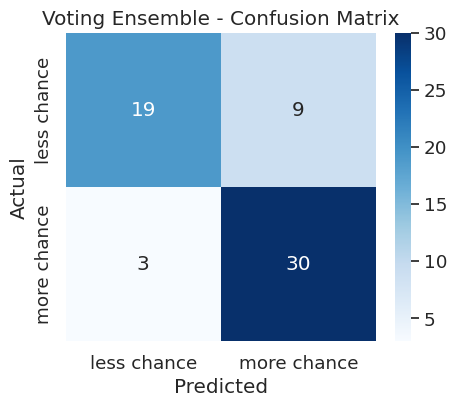

In [14]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting="soft"
)
voting.fit(X_train, y_train)

y_pred = voting.predict(X_test)
y_prob = voting.predict_proba(X_test)[:, 1]

print(f"Voting test accuracy: {voting.score(X_test, y_test):.3f}")
print(f"Voting AUC: {roc_auc_score(y_test, y_prob):.3f}\n")
print(classification_report(y_test, y_pred, target_names=labels))
plot_confusion(y_test, y_pred, "Voting Ensemble - Confusion Matrix")

In [15]:
import joblib

# One example patient (values are made up; keep the column order of the dataset)
new_patient = pd.DataFrame([{
    "age": 54, "sex": 1, "cp": 2, "trestbps": 130, "chol": 246,
    "fbs": 0, "restecg": 1, "thalach": 150, "exang": 0,
    "oldpeak": 1.0, "slope": 1, "ca": 0, "thal": 2
}])[X.columns]

new_scaled = pd.DataFrame(scaler.transform(new_patient), columns=X.columns)

model = models["RF"]
pred = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0, 1]

print(f"Prediction : {labels[pred]}")
print(f"Probability of 'more chance': {prob:.1%}")

# Save the model and scaler together
joblib.dump({"model": model, "scaler": scaler, "columns": list(X.columns)},
            "/kaggle/working/heart_model.joblib")
print("Saved to /kaggle/working/heart_model.joblib")

Prediction : more chance
Probability of 'more chance': 80.0%
Saved to /kaggle/working/heart_model.joblib


In [16]:
print("Rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", len(df))

Rows: 303
Duplicate rows: 1
Rows after removing duplicates: 302


## Conclusion
- Four classifiers (KNN, MLP, AdaBoost, Random Forest) were compared using 5-fold cross-validation and a held-out test set.
- Scaling was fitted on training data only to avoid data leakage.
- The best model was chosen using test accuracy and AUC (see the summary table above).
- **Limitation:** the dataset is small (about 300 rows), so results can change with a different split. This is a learning project, not a medical tool.